## Breast Cancer Prediction

### Data Description-

<br>**1) ID number
<br>**2) Diagnosis** (M = malignant, B = benign)
<br>Ten real-valued features are computed for each cell nucleus:

<br>**a) radius** (mean of distances from center to points on the perimeter)
<br>**b) texture** (standard deviation of gray-scale values)
<br>**c) perimeter
<br>**d) area
<br>**e) smoothness** (local variation in radius lengths)
<br>**f) compactness** (perimeter^2 / area - 1.0)
<br>**g) concavity** (severity of concave portions of the contour)
<br>**h) concave points** (number of concave portions of the contour)
<br>**i) symmetry**

In [1]:
#Importing necessary libraries.
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import os

In [2]:
#Importing warnings library so as to remove warnings from the output.
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#Reading the data set.
bcancer = pd.read_csv("../input/data.csv")
bcancer.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN


In [4]:
#Checking the dimensions of the data set.
bcancer.shape

(569, 33)

In [5]:
#Checking the data types of the variables.
bcancer.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [6]:
bcancer.drop('Unnamed: 32', axis = 1, inplace = True)

In [7]:
#Dropping the ID column as it is not important.
bcancer.drop('id',axis = 1, inplace=True)

In [8]:
#checking for missing values.
bcancer.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [9]:
#Checking the summary statistics of the object attribute 'diagnosis'.
bcancer.describe(include='object')

,diagnosis
count,569
unique,2
top,B
freq,357


In [10]:
#Checking the summary statistics of the numeric attributes.
bcancer.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [11]:
bcancer.groupby('diagnosis').mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.220380,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


In [12]:
#Converting the target variable in to integer where B is 0 and M is 1.
bcancer['diagnosis'] = (bcancer['diagnosis'] == 'M').astype('int')

In [13]:
#Checking the count of Malignant as well as Beningn observations.
bcancer['diagnosis'].value_counts()

0    357
1    212
Name: diagnosis, dtype: int64

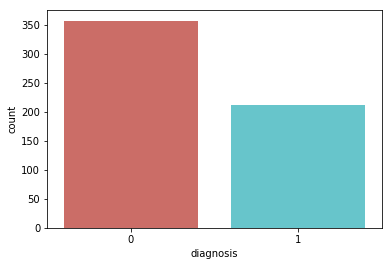

In [14]:
#Visualizing the count of values in diagnosis variable.
sns.countplot(x='diagnosis',data = bcancer,palette='hls')
plt.show()

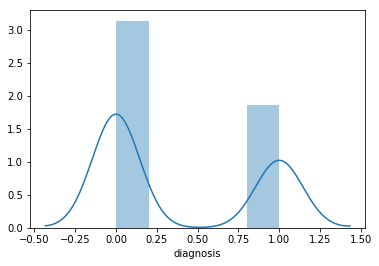

In [15]:
#Checking the distribution of the variable 'diagnosis.'
sns.distplot(bcancer['diagnosis'])

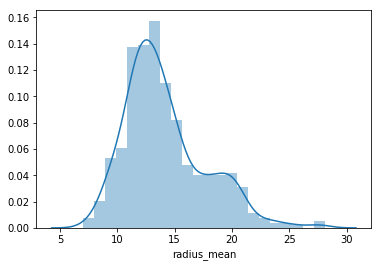

In [16]:
#Checking the distribution of the attribute radius mean.
sns.distplot(bcancer['radius_mean'])

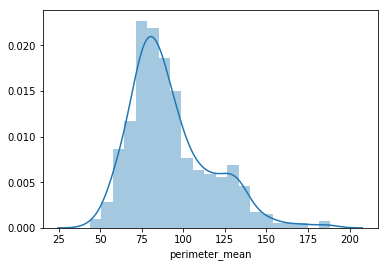

In [17]:
#Checking the distribution of the attribute perimeter mean.
sns.distplot(bcancer['perimeter_mean'])

In [18]:
#Nucleus features vs diagnosis
features_mean=list(bcancer.columns[1:11])
# split dataframe into two based on diagnosis
bcancer_M = bcancer[bcancer['diagnosis'] == 1]
bcancer_B = bcancer[bcancer['diagnosis'] == 0]

/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


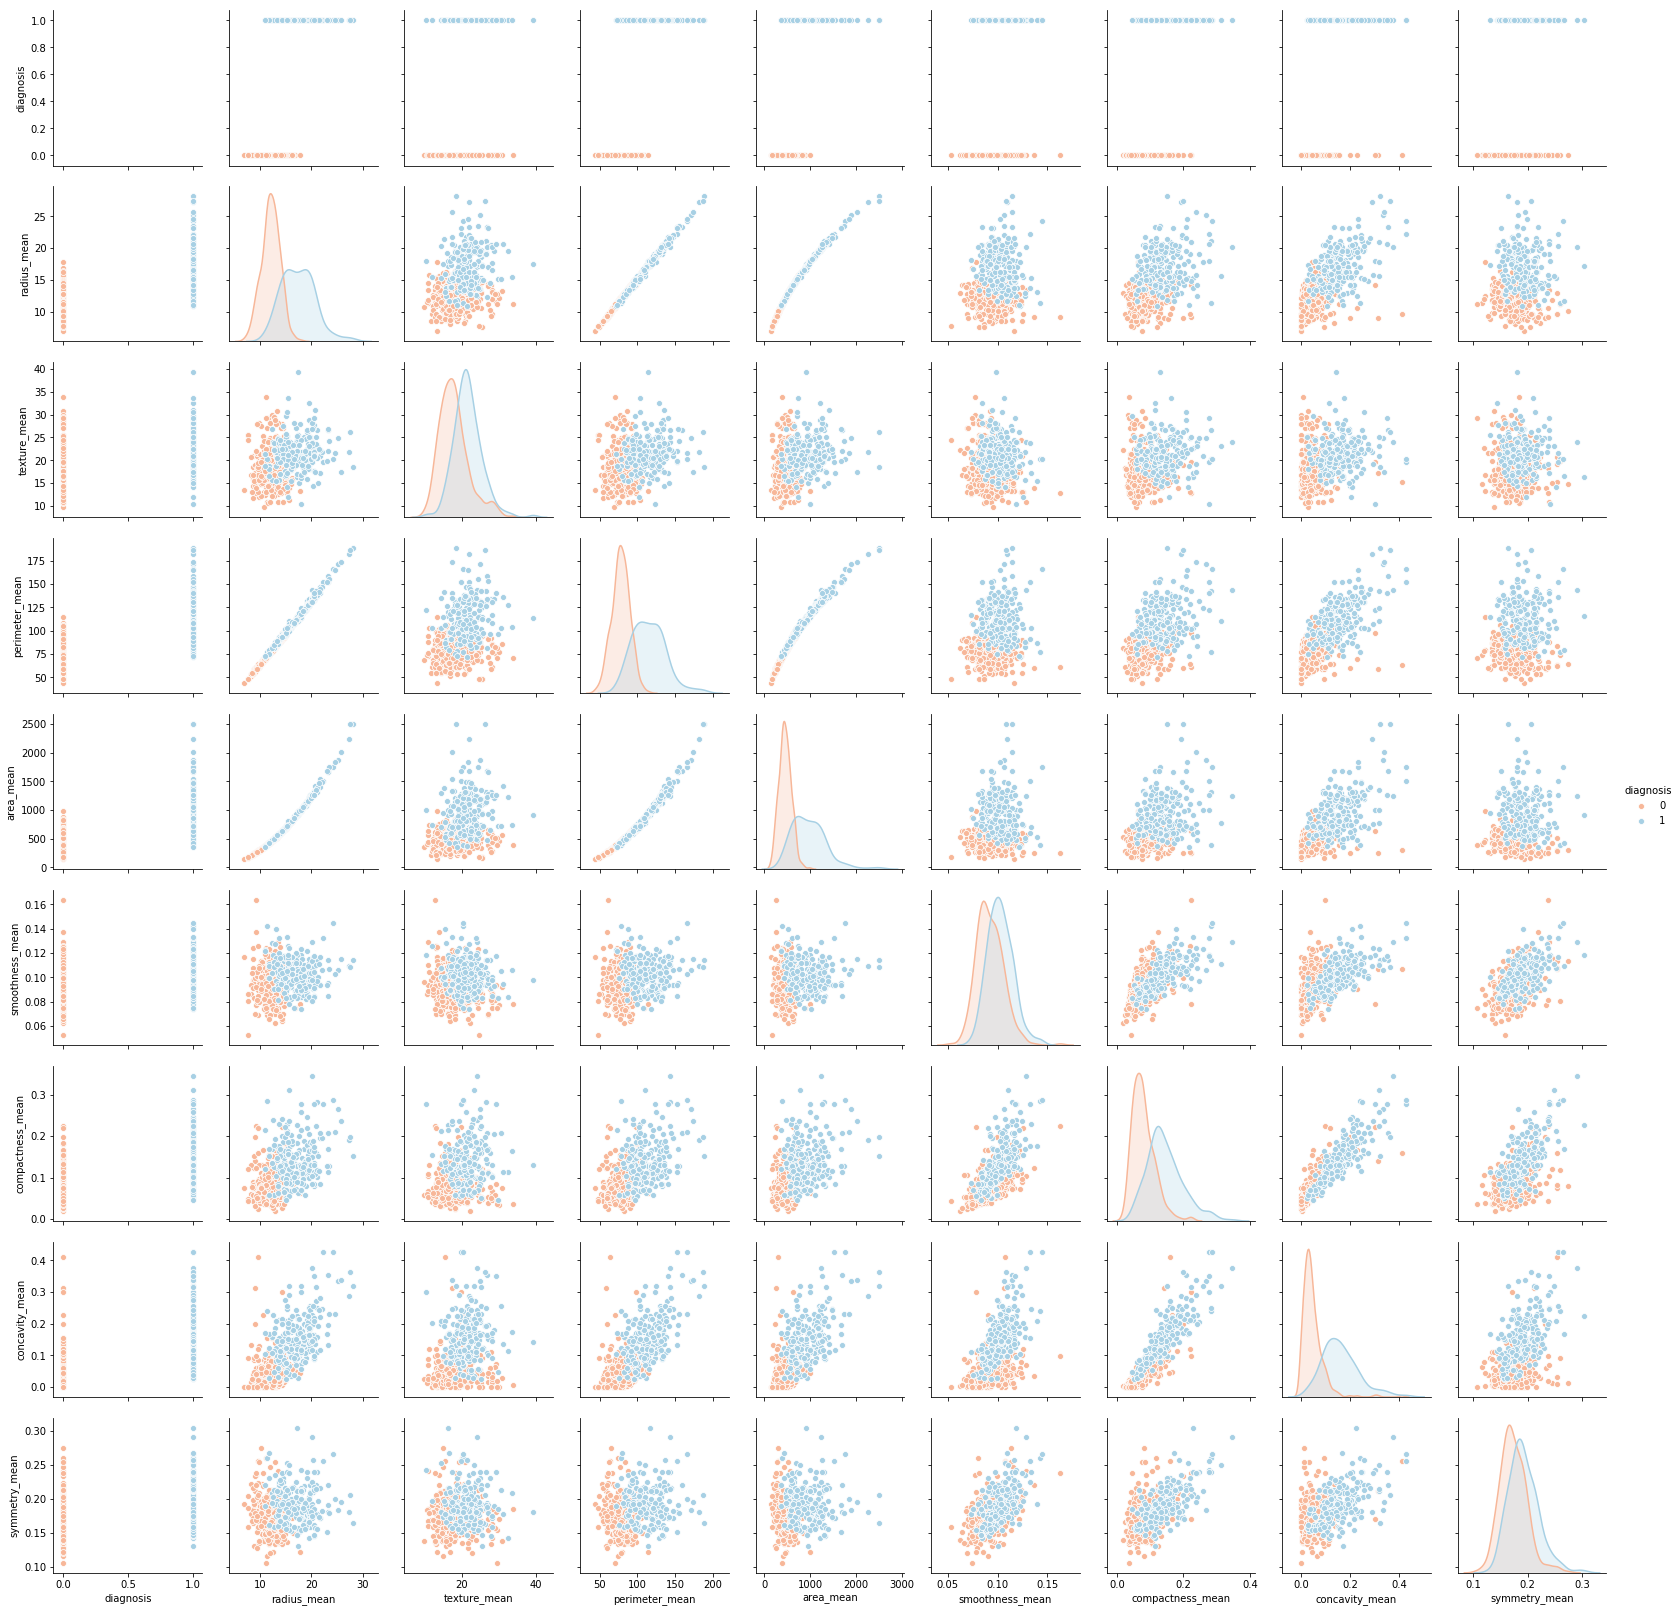

In [19]:
#Genrating a scatter plot matrix with the "mean" columns
cols = ['diagnosis',
        'radius_mean', 
        'texture_mean', 
        'perimeter_mean', 
        'area_mean', 
        'smoothness_mean', 
        'compactness_mean', 
        'concavity_mean', 
        'symmetry_mean']

sns.pairplot(data = bcancer[cols], hue = 'diagnosis', palette = 'RdBu')

There are almost perfectly linear patterns between the radius, perimeter and area attributes which hint at the presence of multicollinearity between these variables. Another set of variables that possibly imply multicollinearity are the concavity, concave_points and compactness.

I have also genrated a correlation matrix in the cells below to show multicollinearity among variables. 

/opt/conda/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


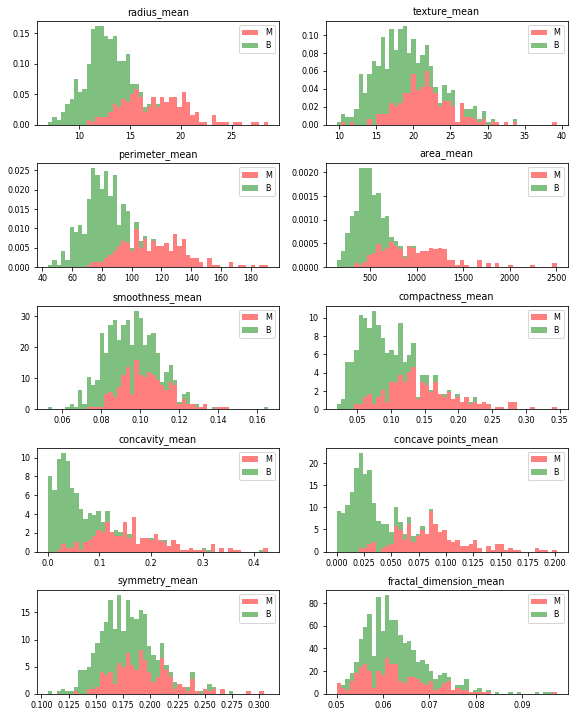

In [20]:
#Stacking the data
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8,10))
axes = axes.ravel()
for idx,ax in enumerate(axes):
    ax.figure
    binwidth= (max(bcancer[features_mean[idx]]) - min(bcancer[features_mean[idx]]))/50
    ax.hist([bcancer_M[features_mean[idx]],bcancer_B[features_mean[idx]]], bins=np.arange(min(bcancer[features_mean[idx]]), \
                        max(bcancer[features_mean[idx]]) + binwidth, binwidth) , alpha=0.5,stacked=True, \
                        normed = True, label=['M','B'],color=['r','g'])
    ax.legend(loc='upper right')
    ax.set_title(features_mean[idx])
plt.tight_layout()
plt.show()

Here we can see the mean values of cell radius, perimeter, area, compactness, concavity and concave points can be used in classification of the cancer. Larger values of these parameters tends to show a correlation with malignant tumors.
Mean values of texture, smoothness, symmetry or fractual dimension does not show a particular preference of one diagnosis over the other. In any of the above histograms there are no noticeable large outliers that requires further cleanup.

## Building the logistic model with all the attributes.

In [21]:
x=bcancer.iloc[:,1:31]
y=bcancer['diagnosis']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = .2, random_state=10) 

In [22]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [23]:
#Displaying all the columns.
pd.options.display.max_columns = None
x_train.head(3)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.061580,0.071170,0.016640,0.02324,0.006185,25.74,39.42,184.60,1821.0,0.1650,0.8681,0.93870,0.26500,0.4087,0.12400
295,13.77,13.27,88.06,582.7,0.09198,0.06221,0.01063,0.01917,0.1592,0.05912,0.2191,0.6946,1.479,17.74,0.004348,0.008153,0.004272,0.006829,0.02154,0.001802,14.67,16.93,94.17,661.1,0.1170,0.1072,0.03732,0.05802,0.2823,0.06794
91,15.37,22.76,100.20,728.2,0.09200,0.10360,0.11220,0.07483,0.1717,0.06097,0.3129,0.8413,2.075,29.44,0.009882,0.024440,0.045310,0.017630,0.02471,0.002142,16.43,25.84,107.50,830.9,0.1257,0.1997,0.28460,0.14760,0.2556,0.06828


In [24]:
#Creating an instance of logistic regression model
from sklearn.linear_model import LogisticRegression
logistic_model1 = LogisticRegression()

#We fit our model to data
fitted_model1 = logistic_model1.fit(x_train,y_train)

#We use predict_proba() to predict the probabilities
predictedvalues1 = fitted_model1.predict(x_test)

#We print the probabilites to take a glance
print(predictedvalues1)

[1 0 0 1 0 0 0 1 1 1 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0
 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0
 0 1 1]


In [25]:
#Checking the accuracy of the above model.
print('Accuracy of logistic regression classifier on test set: {:.3f}'.format(logistic_model1.score(x_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.939


In [26]:
#Generating the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix1 = confusion_matrix(y_test,predictedvalues1)
print(confusion_matrix1)

[[70  5]
 [ 2 37]]


In [27]:
#Calculating sensitivity and specificity
total=sum(sum(confusion_matrix1))

sensitivity1 = confusion_matrix1[0,0]/(confusion_matrix1[0,0]+confusion_matrix1[1,0])
print('Sensitivity : ', sensitivity1 )

specificity1 = confusion_matrix1[1,1]/(confusion_matrix1[1,1]+confusion_matrix1[0,1])
print('Specificity : ', specificity1)

Sensitivity :  0.9722222222222222
Specificity :  0.8809523809523809


Area under the curve: 0.941


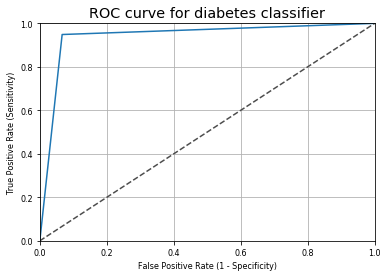

In [28]:
#Generating the roc and calculating the auc.
fpr, tpr, thresholds = roc_curve(y_test, predictedvalues1)

fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c=".3")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve for diabetes classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
print("Area under the curve: {:.3f}".format(auc(fpr,tpr)))

In [29]:
#Generating the classification report.
from sklearn.metrics import classification_report
print(classification_report(y_test, predictedvalues1))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        75
           1       0.88      0.95      0.91        39

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



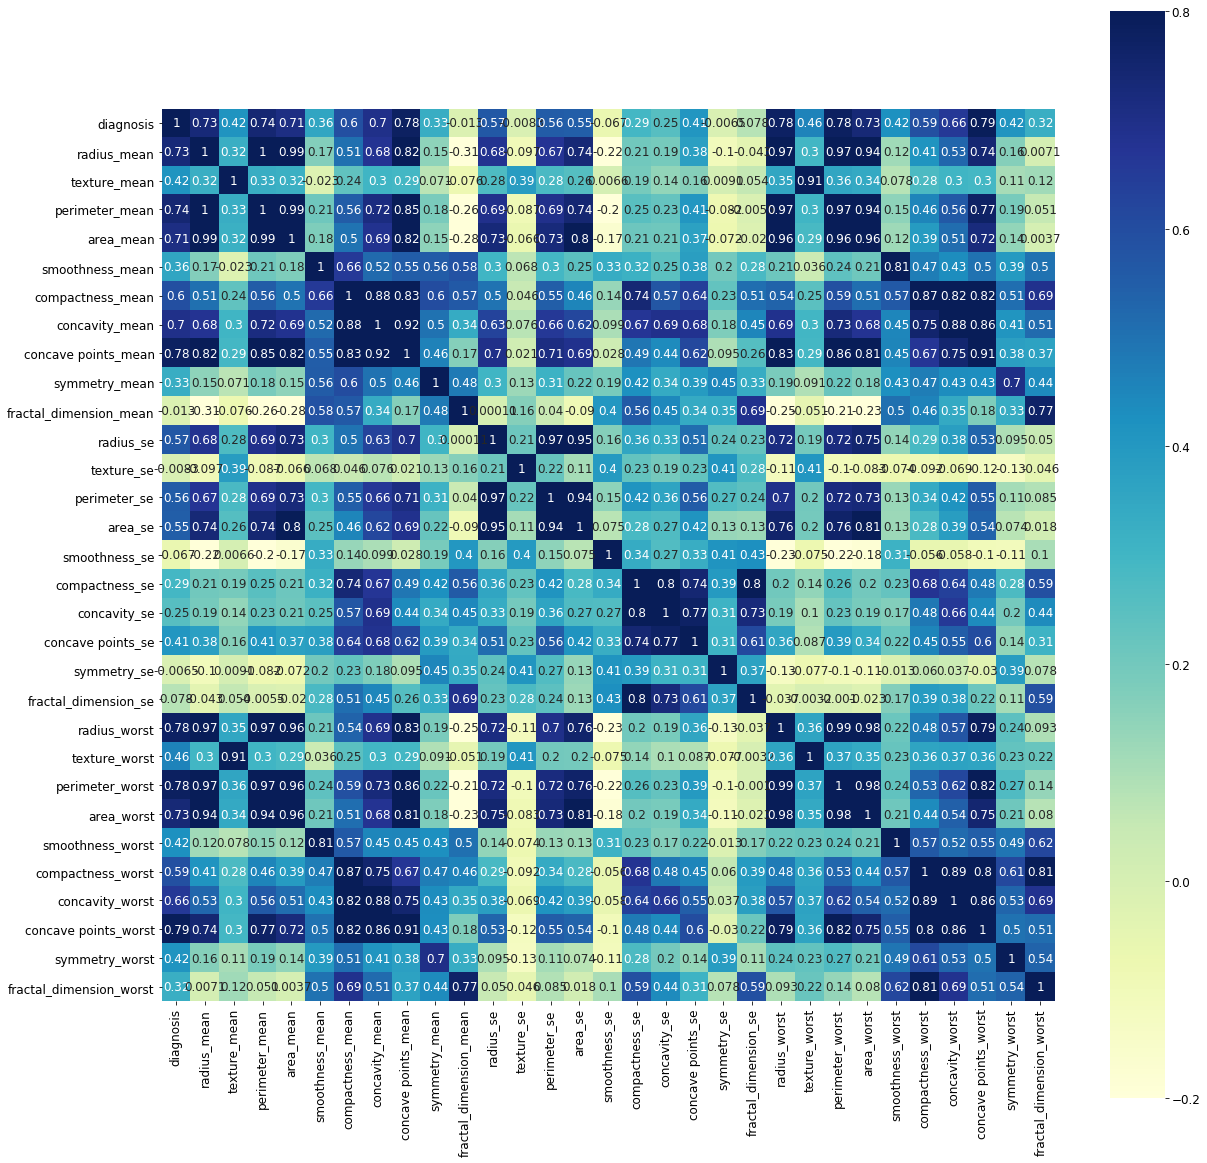

In [30]:
#Generating the correlation matrix.
fig, ax=plt.subplots(figsize=(20,20))
correlation=bcancer.corr()
sns.heatmap(correlation,square=True, vmin=-0.2, vmax=0.8,cmap="YlGnBu", annot=True)

As seen in the heatmap above- radius_mean, perimeter_mean, texture_mean, area_mean, radius_worst, perimeter_worst are highly correlated.

Also here we can see that there is multicollinearity between "mean" columns and the "worst" column. For instance, the radius_mean column has a correlation of 0.97 with the radius_worst column. In fact, each of the 10 key attributes display very high (from 0.7 up to 0.97) correlations between its "mean" and "worst" columns. This shows that the "worst" columns are essentially just a subset of the "mean" columns; the "worst" columns are also the "mean" of some values (the three largest values among all observations). Therefore, I think we can discard the "worst" columns from our analysis and only focus on the "mean" columns.

So here we will drop all "worst" columns from the dataset, and pick only one of the three attributes that describe the size of cells. 

Since a cell's **radius** is the basic building block of its size. Therefore, it is reasonable to choose radius as our attribute to represent the size of a cell.

Also there is multicollinearity between the attributes compactness, concavity. So similarly what we did with the size attributes, here also we should pick only one of these three attributes that contain information on the shape of the cell. So we will take compactness attribute as it somewhat describes the size of the cell, and remove the other attribute.

### So now we will remove the unnecessary columns.

In [31]:
#Dropping all "worst" columns. 
cols = ['radius_worst', 
        'texture_worst', 
        'perimeter_worst', 
        'area_worst', 
        'smoothness_worst', 
        'compactness_worst', 
        'concavity_worst', 
        'symmetry_worst']      
bcancer = bcancer.drop(cols, axis = 1)

In [32]:
#Dropping the perimeter and area attributes.
cols1 = ['area_se', 'perimeter_se', 'perimeter_mean', 'area_mean']
bcancer = bcancer.drop(cols1, axis = 1)

In [33]:
#Dropping the concavity attributes.
cols2 = ['concavity_mean', 'concavity_se']
bcancer = bcancer.drop(cols2, axis = 1)

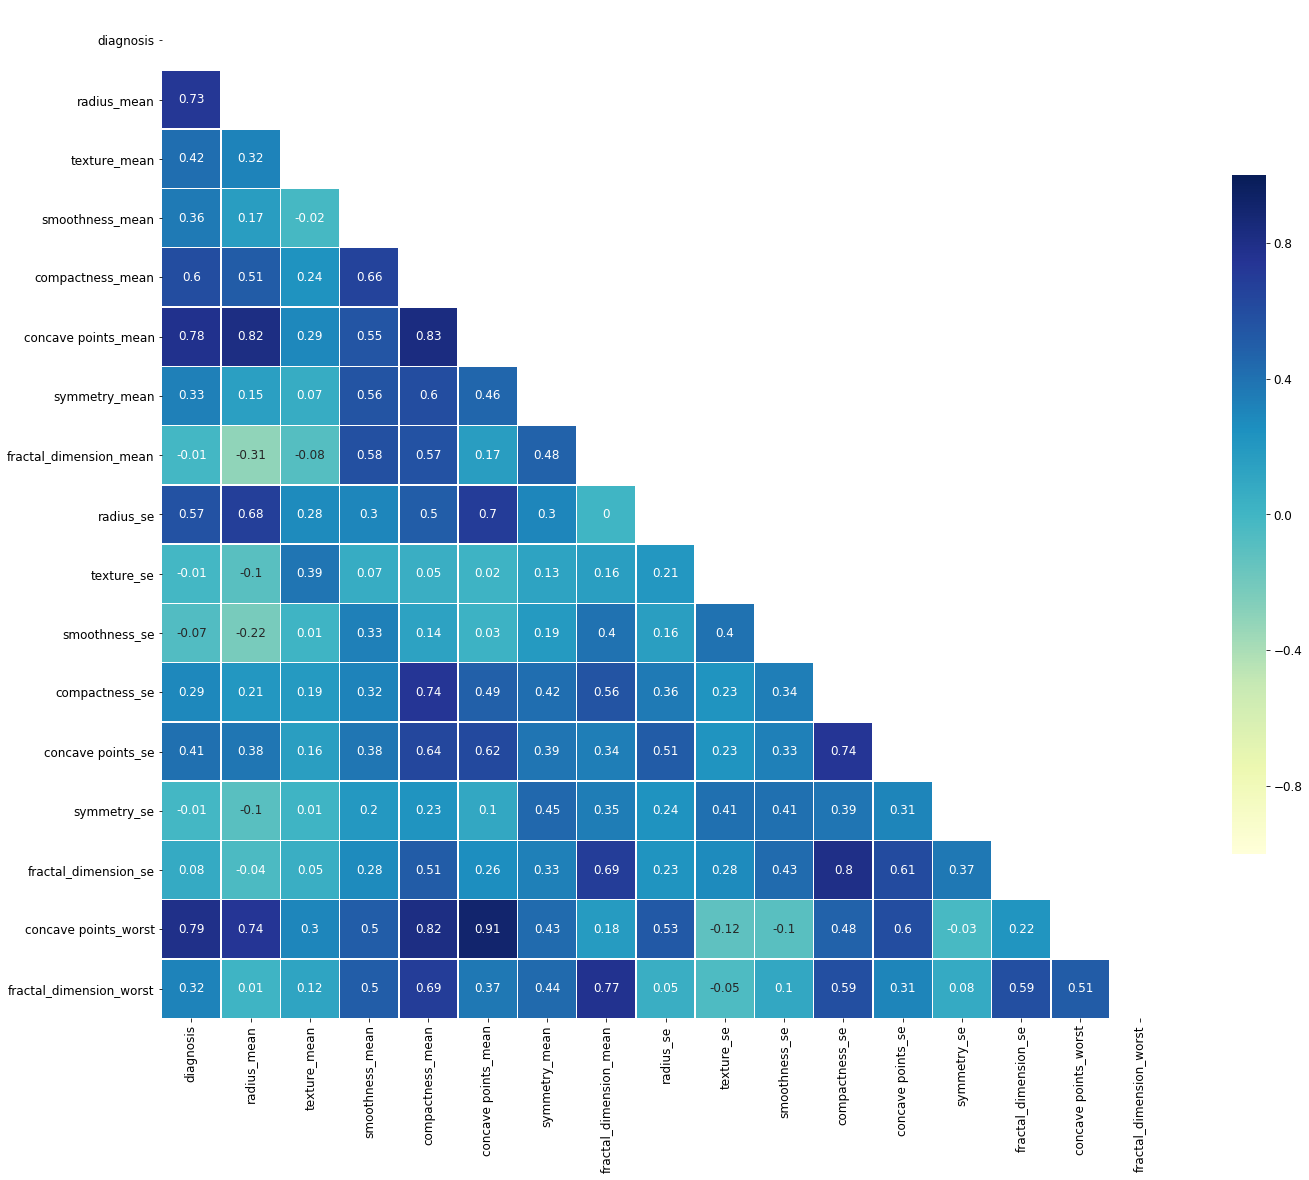

In [34]:
#Drawing the heatmap again, with the new correlation matrix
corr = bcancer.corr().round(2)
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr, mask=mask, cmap='YlGnBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.tight_layout()

## Rebuilding the logistic regression model.

In [35]:
x = bcancer.drop('diagnosis', axis = 1)
y = bcancer['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [36]:
#Checking the shape of train as well as test data.
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 16)
(114, 16)
(455,)
(114,)


In [37]:
#Displaying all the columns.
pd.options.display.max_columns = None
x_train.head(3)

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concave points_se,symmetry_se,fractal_dimension_se,concave points_worst,fractal_dimension_worst
412,9.397,21.68,0.07969,0.06053,0.005128,0.1274,0.06724,0.1186,1.1820,0.005515,0.026740,0.005128,0.01951,0.004583,0.02564,0.09206
461,27.420,26.27,0.10840,0.19880,0.168900,0.2061,0.05623,2.5470,1.3060,0.007650,0.053740,0.025980,0.01697,0.004558,0.26250,0.07427
532,13.680,16.33,0.09277,0.07255,0.018800,0.1631,0.06155,0.2047,0.4801,0.003828,0.007228,0.005077,0.01054,0.001697,0.08704,0.07782


In [38]:
#Creating an instance of logistic regression model
from sklearn.linear_model import LogisticRegression
logistic_model2 = LogisticRegression()

#Fitting our model to data
fitted_model2 = logistic_model2.fit(x_train,y_train)

#We use predict_proba() to predict the probabilities
predictedvalues2 = fitted_model2.predict(x_test)

#We print the probabilites to take a glance
print(predictedvalues2)

[0 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 1
 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0
 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0
 0 0 0]


In [39]:
#Checking the accuracy of the above model.
print('Accuracy of logistic regression classifier on test set: {:.3f}'.format(logistic_model2.score(x_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.921


In [40]:
#Generating the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix2 = confusion_matrix(y_test,predictedvalues2)
print(confusion_matrix2)

[[65  1]
 [ 8 40]]


In [41]:
#Calculating sensitivity and specificity
total=sum(sum(confusion_matrix1))

sensitivity2 = confusion_matrix2[0,0]/(confusion_matrix2[0,0]+confusion_matrix2[1,0])
print('Sensitivity : ', sensitivity2 )

specificity2 = confusion_matrix2[1,1]/(confusion_matrix2[1,1]+confusion_matrix2[0,1])
print('Specificity : ', specificity2)

Sensitivity :  0.8904109589041096
Specificity :  0.975609756097561


Area under the curve: 0.909


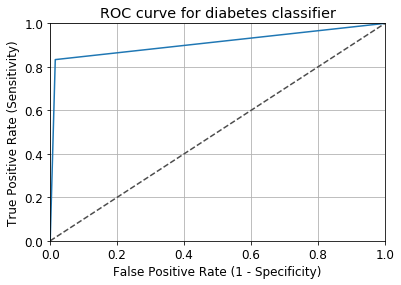

In [42]:
#Generating the roc and calculating the auc.
fpr, tpr, thresholds = roc_curve(y_test, predictedvalues2)

fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], transform=ax.transAxes, ls="--", c=".3")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve for diabetes classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)
print("Area under the curve: {:.3f}".format(auc(fpr,tpr)))

In [43]:
#Generating the classification report.
from sklearn.metrics import classification_report
print(classification_report(y_test, predictedvalues2))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94        66
           1       0.98      0.83      0.90        48

    accuracy                           0.92       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.92      0.92       114



Here we can see after eliminating the multicollinear attributes the accuracy reduced as well as the AUC dropped from 0.945 to 0.909